# Solver settings: time against accuracy

The mesh decides how close the discretised cavity is to the real one; the previous two
examples measure that. The eigensolver's settings decide how close the answer is to the
discretised cavity, and how long it takes to get there. This example measures what each
setting costs and buys, so you can trade accuracy for speed knowingly.

`cav.eigenmode.benchmark` does the measuring. Every point is a complete simulation (mesh,
solve and every figure of merit), repeated five times, and scored against a solve of the
same mesh converged far beyond any setting being compared. The errors here are therefore
the solver's alone. Times are the mean and standard deviation over the repeats. Errors
vary over orders of magnitude from run to run, so each is the mean of its logarithm, drawn
with a spread of $10^{\mu\pm\sigma}$.

The settings compared:

| setting | what it does |
|---|---|
| `pinvit_tol` | the eigensolver stops once every checked mode's relative residual is below it (default `1e-8`) |
| `pinvit_converge_modes` | how many of the lowest modes must converge (default: all `n_modes`) |
| `preconditioner` | `'direct'` (default), an exact factorisation, or `'bddc'`, an approximate one |
| `direct_solver` | the sparse direct solver for every factorisation (default `'sparsecholesky'`) |

The timings are from the machine that built these pages. Run the notebook on yours to get
your own; it is also the way to check a new setting, which is one more entry in
`variants`.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.printing import set_verbose
from cavsim2d.utils.style import apply_style

set_verbose(False)
apply_style()
WORK = tempfile.mkdtemp()

MID = [42, 42, 12, 19, 35, 57.652, 103.3536]      # TESLA mid-cell: A, B, a, b, Ri, L, Req [mm]
CONFIG = {'boundary_conditions': 'mm', 'mesh_config': {'h': 20, 'p': 3}}   # the defaults
TOLERANCES = [1e-4, 1e-6, 1e-8, 1e-10]


def tesla(n_cells):
    cav = EllipticalCavity(n_cells, MID, MID, MID, beampipe='both', name=f'tesla_{n_cells}cell')
    cav.set_workspace(os.path.join(WORK, cav.name))
    return cav


def show(table):
    '''Round a benchmark table for reading.'''
    fmt = {c: '{:.1e}' for c in table.columns}
    fmt.update({'time per simulation [s]': '{:.2f}', 'std [s]': '{:.2f}',
                'solve [s]': '{:.2f}', 'PINVIT iterations': '{:.0f}'})
    return table.style.format(fmt).format_index(
        lambda v: f'{v:.0e}' if isinstance(v, float) else v)

## 1. Tolerance and preconditioner on a single cell

A TESLA mid-cell with beam pipes, on the default mesh. The direct and BDDC preconditioners
are each run at four tolerances.

In [2]:
cell = tesla(1)
cell.eigenmode.benchmark(variants={'direct': {}, 'bddc': {'preconditioner': 'bddc'}},
                         sweep={'pinvit_tol': TOLERANCES}, n_repeats=5,
                         eigenmode_config=CONFIG)
show(cell.eigenmode.benchmark_table())

Each column is a worst relative error over the modes reported: the frequency of the mode of
interest (the accelerating mode), of the passband (the lowest `n_cells` modes) and of every
reported mode, then R/Q, Epk/Eacc and Bpk/Eacc over the modes that carry a voltage, and G over
every mode.

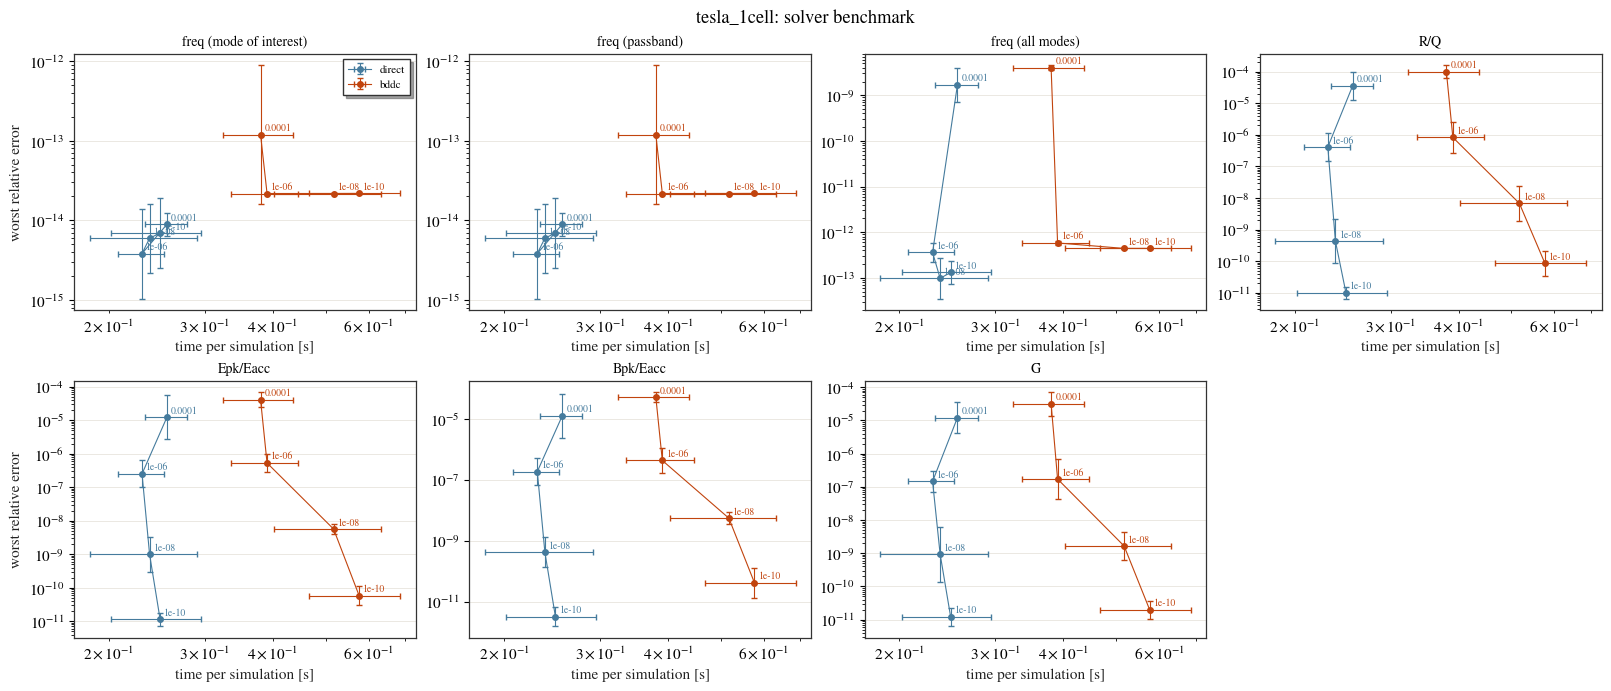

In [3]:
cell.eigenmode.plot_benchmark()
plt.show()

On a single cell the direct preconditioner is the faster of the two at every tolerance:
0.23 to 0.26 s per simulation against 0.38 to 0.58 s for BDDC. BDDC needs about six times as
many iterations (52 to 138 against 9 to 22), and each one is not correspondingly cheaper.
Direct iterations are so cheap here that tightening the tolerance from $10^{-4}$ to
$10^{-10}$ costs nothing measurable: meshing and the figures of merit take most of the time.

The tolerance buys accuracy in the fields, close to one decade for one decade. At the
default `1e-8` every figure of merit is within $10^{-9}$ of the reference; at `1e-4`, R/Q is
within $4\times10^{-5}$. The frequencies converge far faster than the fields: at `1e-4` the
accelerating mode's frequency is already exact to round-off.

## 2. Nine cells: a passband, and the modes above it

A 9-cell reports `n_cells + 2 = 11` modes by default: the nine of the accelerating passband
and the lowest two of the next band. The eigensolver converges a group of closely spaced
modes more slowly, and those two, at the bottom of a dense band, slowest of all.

In [4]:
nine = tesla(9)
nine.eigenmode.benchmark(variants={'direct': {}, 'bddc': {'preconditioner': 'bddc'}},
                         sweep={'pinvit_tol': TOLERANCES}, n_repeats=5,
                         eigenmode_config=CONFIG)
show(nine.eigenmode.benchmark_table())

C:\Users\Soske\Documents\git_projects\cavsim2d\cavsim2d\solvers\NGSolve\eigen_ngsolve.py:2125: UserWarning: PINVIT stopped at pinvit_maxit=2000 with a relative residual of 5.3e-10 against pinvit_tol=1e-10, so the highest checked modes are not converged. Raise eigenmode_config['pinvit_maxit'], loosen 'pinvit_tol', or check fewer modes with 'pinvit_converge_modes'.
  freq_fes, gfu_E, gfu_H = self._solve_system(system, n_modes, **pinvit)


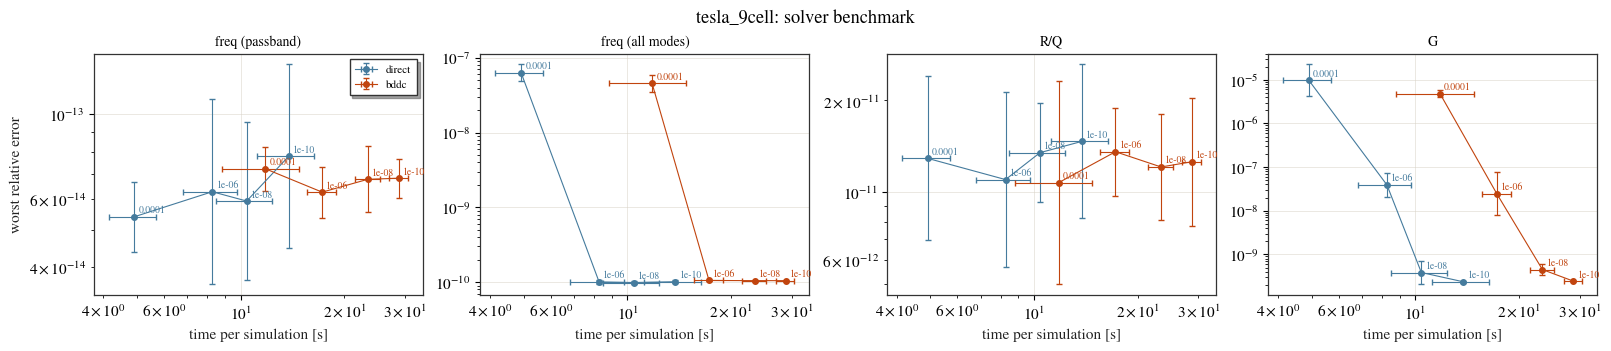

In [5]:
nine.eigenmode.plot_benchmark(errors=['freq (passband)', 'freq (all modes)', 'R/Q', 'G'])
plt.show()

The frequency error of every mode, for the direct preconditioner at each tolerance: modes 1
to 9 are the passband, 10 and 11 the next band.

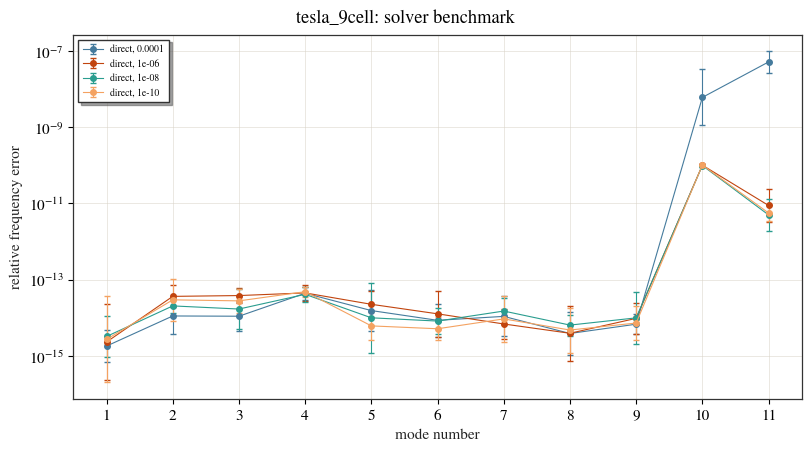

In [6]:
bench = nine.eigenmode.benchmark_df
nine.eigenmode.plot_benchmark(bench[bench['variant'] == 'direct'], kind='modes')
plt.show()

On nine cells the solve dominates the time, and both settings show. Direct takes 4.9 s at
`1e-4` and 10.4 s at the default `1e-8`. BDDC takes more than twice as long at every
tolerance, 11.8 to 28.8 s, with about three times the iterations.

Almost all of those iterations go to the two modes above the passband. The per-mode plot
shows it: the nine passband modes are converged to round-off at every tolerance, `1e-4`
included, while modes 10 and 11 follow the tolerance. So the passband's figures of merit
are converged to about $10^{-11}$ whatever the tolerance, and only the all-modes frequency
and G, which is scored over every reported mode, respond to it.

## 3. Converging the passband only

If only the passband will be used, `pinvit_converge_modes=9` stops the solve once those nine
have converged. The two modes above are still reported, but not converged.

In [7]:
nine.eigenmode.benchmark(variants={'every mode (default)': {},
                                   'passband only': {'pinvit_converge_modes': 9}},
                         sweep={'pinvit_tol': [1e-6, 1e-8]}, n_repeats=5,
                         eigenmode_config=CONFIG)
show(nine.eigenmode.benchmark_table())

Converging the passband alone takes 9 to 11 iterations and 1.8 s per simulation, instead of
7.9 to 11.6 s: four to six times faster, with the passband exactly as accurate (R/Q to
$4\times10^{-8}$ at a tolerance of `1e-6`, $7\times10^{-10}$ at `1e-8`). The price is the two
modes above. Nothing converged them, so their frequencies are up to 1 % off and their G
several per cent. Use it when those modes will not be read. Setting `n_modes=n_cells` does
the same without reporting them at all.

## 4. The sparse direct solver

Which sparse direct solvers are available depends on how NGSolve was built:
`sparsecholesky` always is, `pardiso` and `umfpack` depend on the build. A variant asking
for one this build lacks is skipped with a warning.

In [8]:
backends = {'sparsecholesky': {}, 'pardiso': {'direct_solver': 'pardiso'},
            'umfpack': {'direct_solver': 'umfpack'}}
for cav in (cell, nine):
    cav.eigenmode.benchmark(variants=backends, n_repeats=3, eigenmode_config=CONFIG)
    display(show(cav.eigenmode.benchmark_table()))

C:\Users\Soske\AppData\Local\Temp\ipykernel_40572\2965386525.py:4: UserWarning: benchmark: skipping 'umfpack', this NGSolve build has no 'umfpack' direct solver.
  cav.eigenmode.benchmark(variants=backends, n_repeats=3, eigenmode_config=CONFIG)


,time per simulation [s],std [s],solve [s],PINVIT iterations,freq (mode of interest),freq (passband),freq (all modes),R/Q,Epk/Eacc,Bpk/Eacc,G
variant,,,,,,,,,,,
sparsecholesky,0.26,0.02,0.18,17,5.0e-15,5.0e-15,1.2e-13,7.7e-10,3.4e-10,4.4e-10,1.9e-09
pardiso,2.71,0.18,2.63,17,1.2e-14,1.2e-14,1.2e-13,2.1e-09,6.5e-10,1.1e-09,7.6e-10


C:\Users\Soske\AppData\Local\Temp\ipykernel_40572\2965386525.py:4: UserWarning: benchmark: skipping 'umfpack', this NGSolve build has no 'umfpack' direct solver.
  cav.eigenmode.benchmark(variants=backends, n_repeats=3, eigenmode_config=CONFIG)


,time per simulation [s],std [s],solve [s],PINVIT iterations,freq (mode of interest),freq (passband),freq (all modes),R/Q,Epk/Eacc,Bpk/Eacc,G,ff
variant,,,,,,,,,,,,
sparsecholesky,13.85,1.50,12.31,206,5.2e-15,6.4e-14,5.9e-12,1.9e-11,9.6e-12,1.2e-11,3.6e-10,1.1e-11
pardiso,105.16,2.53,103.99,250,1.8e-14,5.1e-14,4.5e-12,1.5e-11,9.7e-12,1.0e-11,3.7e-10,1.6e-11


Both backends give the same answer, and `sparsecholesky` is the faster: ten times on the
single cell (0.26 s against 2.7 s) and almost eight times on nine cells (14 s against
105 s). This build has no `umfpack`, so that variant was skipped. On a build that has it,
the same cell compares all three.

## 5. What to use

- The defaults (the direct preconditioner, `sparsecholesky`, `pinvit_tol=1e-8`) keep the
  solver's error far below any practical mesh's: figures of merit to about $10^{-9}$,
  frequencies to round-off.
- BDDC did not win anywhere here. On both cavities it was 1.5 to 2.4 times slower, at
  every tolerance.
- The tolerance is a free knob on small problems and a real one on large ones. On nine
  cells `1e-4` halves the default's time and still leaves the passband at round-off, with
  G and the modes above the passband at $10^{-5}$ and $10^{-7}$.
- On a multicell cavity the largest saving is to converge only the modes you will use:
  `pinvit_converge_modes=n_cells`, or `n_modes=n_cells`.
- Keep `direct_solver='sparsecholesky'` unless a benchmark on your own machine says
  otherwise.